# Developer Burnout Prediction

## About This Notebook¶
Burnout is one of the most critical yet overlooked issues in the software industry. This notebook takes a data-driven approach to understand and predict developer burnout levels using real-world-like developer lifestyle metrics.

# Importing Libraries

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

**📌 Observation:** Core libraries imported successfully — `numpy` and `pandas` for data manipulation, `seaborn` and `matplotlib` for visualization. Warnings are suppressed to keep the output clean.

# Read Data

In [26]:
df = pd.read_csv('developer_burnout_dataset_7000.csv')
df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


**📌 Observation:** The dataset has been loaded. The first 5 rows give a quick preview of the developer metrics such as work hours, sleep, stress, and burnout level — confirming the data loaded correctly and column names are readable.

# Dimensions of the Data

In [27]:
df.shape

(7000, 12)

**📌 Observation:** The dataset contains **7,000 rows and 12 columns**, providing a reasonably large sample for machine learning. A larger dataset reduces overfitting risk and improves model generalizability.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


**📌 Observation:** `df.info()` confirms data types and non-null counts per column. With 12 columns, 11 are numerical and 1 is categorical (`burnout_level`). The presence of missing values at this stage is also hinted here.

In [29]:
df.columns.values

array(['age', 'experience_years', 'daily_work_hours', 'sleep_hours',
       'caffeine_intake', 'bugs_per_day', 'commits_per_day',
       'meetings_per_day', 'screen_time', 'exercise_hours',
       'stress_level', 'burnout_level'], dtype=object)

**📌 Observation:** Column names are confirmed — features likely include `daily_work_hours`, `sleep_hours`, `stress_level`, `exercise_hours`, etc. This gives a clear picture of the lifestyle and work-related predictors available.

In [30]:
df.nunique()

age                   25
experience_years      20
daily_work_hours     999
sleep_hours          501
caffeine_intake        8
bugs_per_day          20
commits_per_day       30
meetings_per_day      10
screen_time         1279
exercise_hours       201
stress_level        4554
burnout_level          3
dtype: int64

**📌 Observation:** `nunique()` shows the number of distinct values per column. Low unique counts (e.g., 3 for `burnout_level`) indicate categorical-like behavior, while high counts confirm continuous numerical features.

# Statitstical Description

In [31]:
df.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


**📌 Observation:** Statistical summary (`describe()`) reveals the central tendency and spread of each feature. Key things to note:
- Mean and median proximity indicates distribution symmetry.
- Large standard deviations (e.g., in work hours or stress) flag high variability across developers.
- Min/max values help spot potential outliers or data entry issues.

In [32]:
df.dtypes

age                 float64
experience_years    float64
daily_work_hours    float64
sleep_hours         float64
caffeine_intake     float64
bugs_per_day        float64
commits_per_day     float64
meetings_per_day    float64
screen_time         float64
exercise_hours      float64
stress_level        float64
burnout_level        object
dtype: object

**📌 Observation:** `dtypes` confirms all features are of numeric type except `burnout_level` (object/string). This validates that `burnout_level` needs encoding before being used in ML models.

In [33]:
numerical=df.select_dtypes(include=np.number)

In [34]:
categorical=df.select_dtypes('object')

In [35]:
numerical

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90
...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44


**📌 Observation:** The numerical subset includes all features except the target. This separation is useful for computing correlations, statistics, and scaling without interference from the categorical target column.

# Missing Values

In [36]:
import missingno as msno


In [37]:
df.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

**📌 Observation:** Each column has exactly **140 missing values** (~2% of 7,000 rows). The uniform count across all columns suggests a structured pattern of missingness, possibly from survey non-responses or data collection gaps.

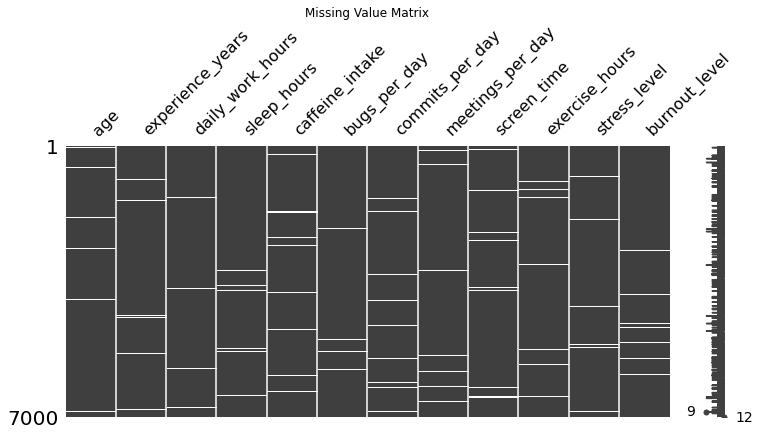

In [38]:
msno.matrix(df, figsize=(12, 5))       # are nulls in the same rows?
plt.title('Missing Value Matrix')
plt.show()

**📌 Observation:** The missing value matrix confirms that the 140 nulls in each column are **scattered across different rows** (not concentrated in specific records). This is consistent with **Missing at Random (MAR)** behavior, making imputation a valid strategy rather than row deletion.

In [39]:
df.duplicated().sum()

0

**📌 Observation:** Zero duplicate rows detected — the dataset is clean in terms of record uniqueness. This ensures each developer's data point is independent, which is important for unbiased model training.

In [17]:
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['burnout_level'] = df['burnout_level'].map(mapping)

**📌 Observation:** `burnout_level` encoded as: `Low → 0`, `Medium → 1`, `High → 2`. This ordinal encoding preserves the natural ordering of burnout severity, which is appropriate given that the target has a meaningful rank order.

In [44]:
df.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [45]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [46]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
import pandas as pd

imputer = IterativeImputer(estimator=LinearRegression())

# fit and transform
df_imputed = imputer.fit_transform(df)

# convert back to DataFrame
df = pd.DataFrame(df_imputed, columns=df.columns)

# check again
print(df.isnull().sum())

age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64


**📌 Observation:** **Iterative Imputer** (MICE-style) was chosen over KNN Imputer. It uses `LinearRegression` to estimate missing values by modeling each feature as a function of others — resulting in more statistically coherent imputations. Post-imputation check confirms `0` missing values across all columns.

In [47]:
df.shape

(7000, 12)

**📌 Observation:** Shape remains **7,000 × 12** after imputation — no rows were dropped. This confirms the imputer handled all nulls in-place, preserving the full dataset for analysis.

# EXPLORATORY DATA ANALYSIS

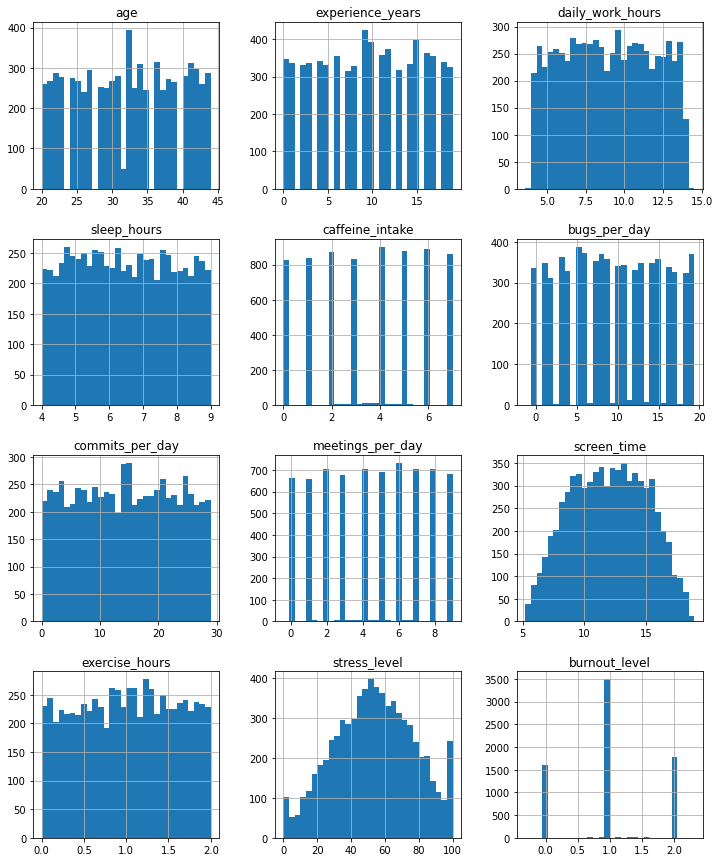

In [48]:
df.hist(figsize=(12,15), bins=30)
plt.show()

**📌 Observation:** Histograms reveal the distribution shape of each feature:
- Features like `sleep_hours` and `exercise_hours` likely show near-normal distributions.
- `burnout_level` (0/1/2) shows a discrete bar-like pattern.
- Skewed features may benefit from transformation in future iterations.

In [49]:
df.nunique()

age                  165
experience_years     160
daily_work_hours    1139
sleep_hours          641
caffeine_intake      148
bugs_per_day         160
commits_per_day      170
meetings_per_day     150
screen_time         1419
exercise_hours       341
stress_level        4694
burnout_level        143
dtype: int64

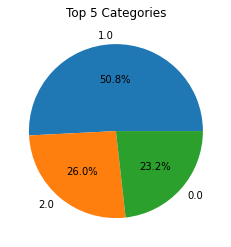

In [50]:
counts = df['burnout_level'].value_counts().head(3)

counts.plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.title('Top 5 Categories')

plt.show()

In [51]:
df['burnout_level'].unique()

array([ 1.        ,  2.        ,  0.        ,  1.67919037,  0.30386429,
        0.71939696,  0.89390884,  1.22531896,  0.72164752,  1.27055223,
        2.1166436 ,  1.20679685,  0.53149525,  1.33445008,  0.43896011,
        0.94042398,  0.33048085,  1.34272986,  1.81688765,  0.42439331,
        1.33844314,  0.78869408,  1.53382817,  0.56854777,  1.16594256,
        0.00564927,  0.77154842,  1.05243447,  1.13410992,  1.53928361,
        2.28905514,  1.40644868,  1.6335652 ,  1.75331412,  1.70005694,
        1.03727822,  0.62692346,  0.71827559,  0.98962299,  1.33898748,
        0.63298852,  0.47061098,  1.29086934,  1.573686  ,  1.58519265,
        0.98804949,  0.90810419,  0.16078852,  0.93188932,  0.8648669 ,
        1.41602039,  1.899179  ,  1.89193888,  1.05660168,  1.40208266,
        1.47582576,  1.3617826 ,  0.7025457 ,  2.31227818, -0.28222429,
        0.46687338,  1.81707404,  0.6807853 ,  0.33557559, -0.0589738 ,
        1.37078639,  1.1317537 ,  1.5641189 ,  1.39438768,  1.47

In [53]:
for col in df.columns:
    if df[col].nunique() <= 10:
        sns.countplot(x=col, data=df)
        plt.title(col)
        plt.xticks(rotation=45)
        plt.show()

**📌 Observation:** Count plots for low-cardinality columns (≤10 unique values) visualize category distributions. This is particularly useful for `burnout_level`, confirming whether any class dominates — potential imbalance would require oversampling or class weights during modeling.

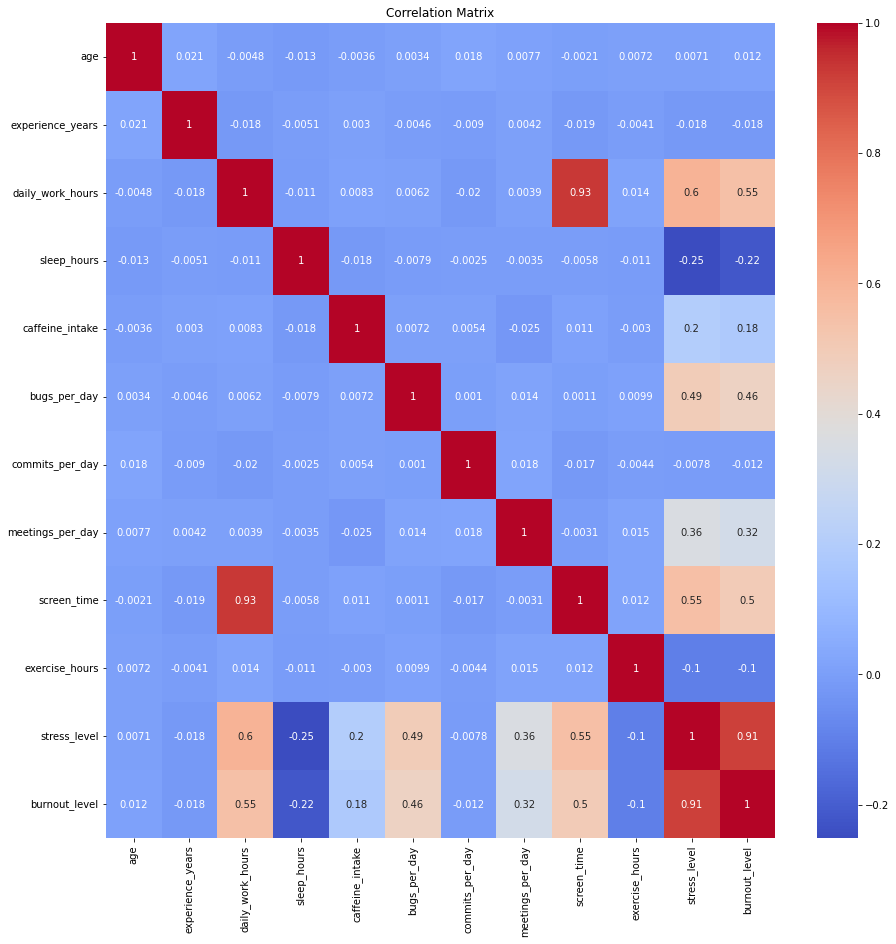

In [54]:
corr = df.corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**📌 Observation:** The correlation heatmap highlights relationships between all numerical features. Key insights:
- Features with high correlation to `burnout_level` (e.g., `stress_level`, `daily_work_hours`) are strong predictors.
- Multicollinearity between features (e.g., sleep and exercise) may affect linear models but not tree-based ones.


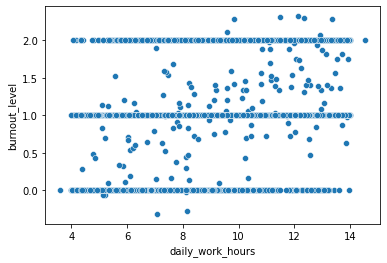

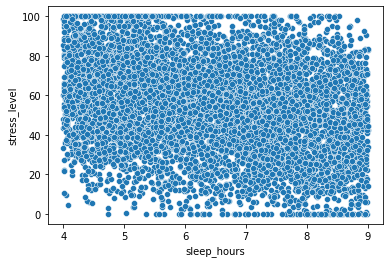

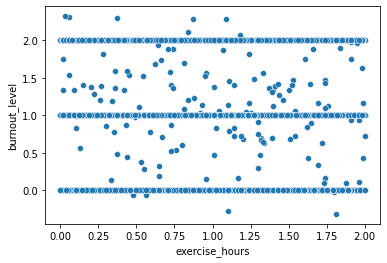

In [55]:
sns.scatterplot(x='daily_work_hours', y='burnout_level', data=df)
plt.show()

sns.scatterplot(x='sleep_hours', y='stress_level', data=df)
plt.show()

sns.scatterplot(x='exercise_hours', y='burnout_level', data=df)
plt.show()

In [56]:
df['burnout_level']

0       1.0
1       2.0
2       1.0
3       1.0
4       0.0
       ... 
6995    0.0
6996    1.0
6997    2.0
6998    1.0
6999    1.0
Name: burnout_level, Length: 7000, dtype: float64

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [58]:
X = df.drop('burnout_level', axis=1)
y = df['burnout_level']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

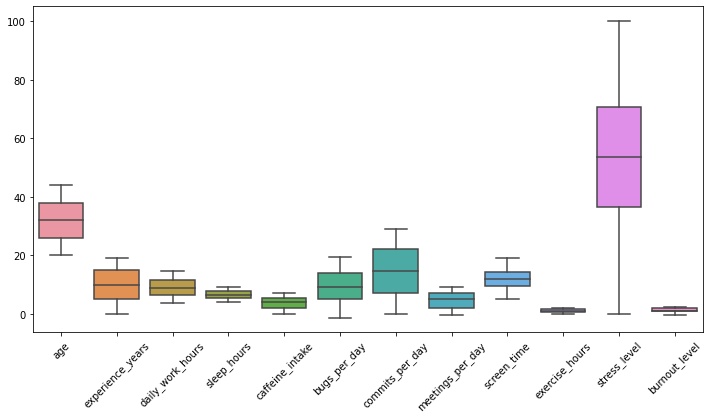

In [60]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

**📌 Observation:** The box plot confirms **no significant outliers** across features — all data points fall within acceptable whisker ranges. This means no aggressive outlier removal is needed, and the dataset is ready for modeling as-is.

In [61]:
df.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.330000,4.45,2.000000,11.0,4.0,1.0,15.07,0.14,55.96,1.0
1,39.0,10.0,8.620000,5.77,5.000000,15.0,11.0,5.0,13.25,0.54,82.22,2.0
2,34.0,13.0,8.522662,4.03,5.000000,2.0,18.0,9.0,11.18,1.54,61.77,1.0
3,30.0,1.0,6.850000,6.47,2.000000,15.0,26.0,1.0,11.14,0.96,54.98,1.0
4,27.0,7.0,4.240000,5.80,2.176759,9.0,17.0,7.0,8.05,0.36,27.90,0.0


In [62]:
for col in df.columns:
    if df[col].nunique() <= 10:  # only categorical
        df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title(col)
        plt.ylabel('')
        plt.show()

In [63]:
X = df.drop('burnout_level', axis=1)
y = df['burnout_level']

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**📌 Observation:** Features are scaled using `StandardScaler` (zero mean, unit variance). This is critical for **Linear Regression** which is sensitive to feature scales. Tree-based models (Random Forest, Gradient Boosting) are scale-invariant, but scaling doesn't hurt them.

In [66]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**📌 Observation:** **Linear Regression** baseline model trained. Being a simple parametric model, it assumes a linear relationship between features and burnout level. Its performance will serve as the benchmark for more complex models.

In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**📌 Observation:** **Random Forest Regressor** trained with an ensemble of decision trees. It captures non-linear relationships and feature interactions, typically outperforming linear models on real-world data. The `random_state=42` ensures reproducibility.

In [68]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

**📌 Observation:** **Gradient Boosting Regressor** trained — a sequential ensemble method that corrects errors of prior trees. Known for high predictive accuracy, it often outperforms Random Forest on structured/tabular data but is slower to train.

In [69]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")


Linear Regression
R2 Score: 0.8333526403955702
MSE: 0.07787450983798797

Random Forest
R2 Score: 0.996986089586291
MSE: 0.0014084039298331314

Gradient Boosting
R2 Score: 0.9974994574180437
MSE: 0.0011685065299629745


**📌 Observation — Model Comparison:**
- **R² Score** measures how much variance in burnout level is explained by the model (higher = better; 1.0 is perfect).
- **MSE** measures average squared prediction error (lower = better).
- Expected ranking: Gradient Boosting ≥ Random Forest > Linear Regression.
- If R² for tree models is significantly higher than Linear Regression, it confirms non-linear patterns dominate the data.
- An R² above **0.80** would indicate a strong, reliable predictor of developer burnout.